# Financial Econometrics I - Homework 1
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)
**Individual contributions**: 

**AI tool usage**:

**Data used**: 73267075

In [ ]:
library(repr)
library(tseries)
library(forecast)
library(stats)
library(FinTS)


Attaching package: 'aTSA'


The following object is masked from 'package:forecast':

    forecast


The following objects are masked from 'package:tseries':

    adf.test, kpss.test, pp.test


The following object is masked from 'package:graphics':

    identify




In [77]:
seriesA <- read.csv("73267075/series_A.csv")
seriesB <- read.csv("73267075/series_B.csv")
seriesC <- read.csv("73267075/series_C.csv")

## Problem 1: Preliminary analysis

In [78]:
cat("Series A - Dimensions:", dim(seriesA), "\n"); head(seriesA)
cat("Series B - Dimensions:", dim(seriesB), "\n"); head(seriesB)
cat("Series C - Dimensions:", dim(seriesC), "\n"); head(seriesC)

Series A - Dimensions: 4000 3 


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.012729479,0.0001099423
2,2,-0.018529822,0.0001163126
3,3,0.007715439,0.0001683621
4,4,0.021651097,0.0001501986
5,5,-0.003913673,0.0001762050
6,6,-0.004157253,0.0001409973


Series B - Dimensions: 4000 3 


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,0.029356436,0.0003128726
2,2,0.016784537,0.0004485798
3,3,0.024271265,0.0003856098
4,4,-0.018726495,0.0004203585
5,5,-0.012681055,0.0004587874
6,6,-0.005705462,0.0003815353


Series C - Dimensions: 4000 3 


,t,ret,sigma2_true
,<int>,<dbl>,<dbl>
1,1,-0.0009315538,1e-04
2,2,0.0038711102,1e-04
3,3,0.0166130868,1e-04
4,4,0.0088461616,1e-04
5,5,0.0019757394,1e-04
6,6,-0.0134267758,1e-04


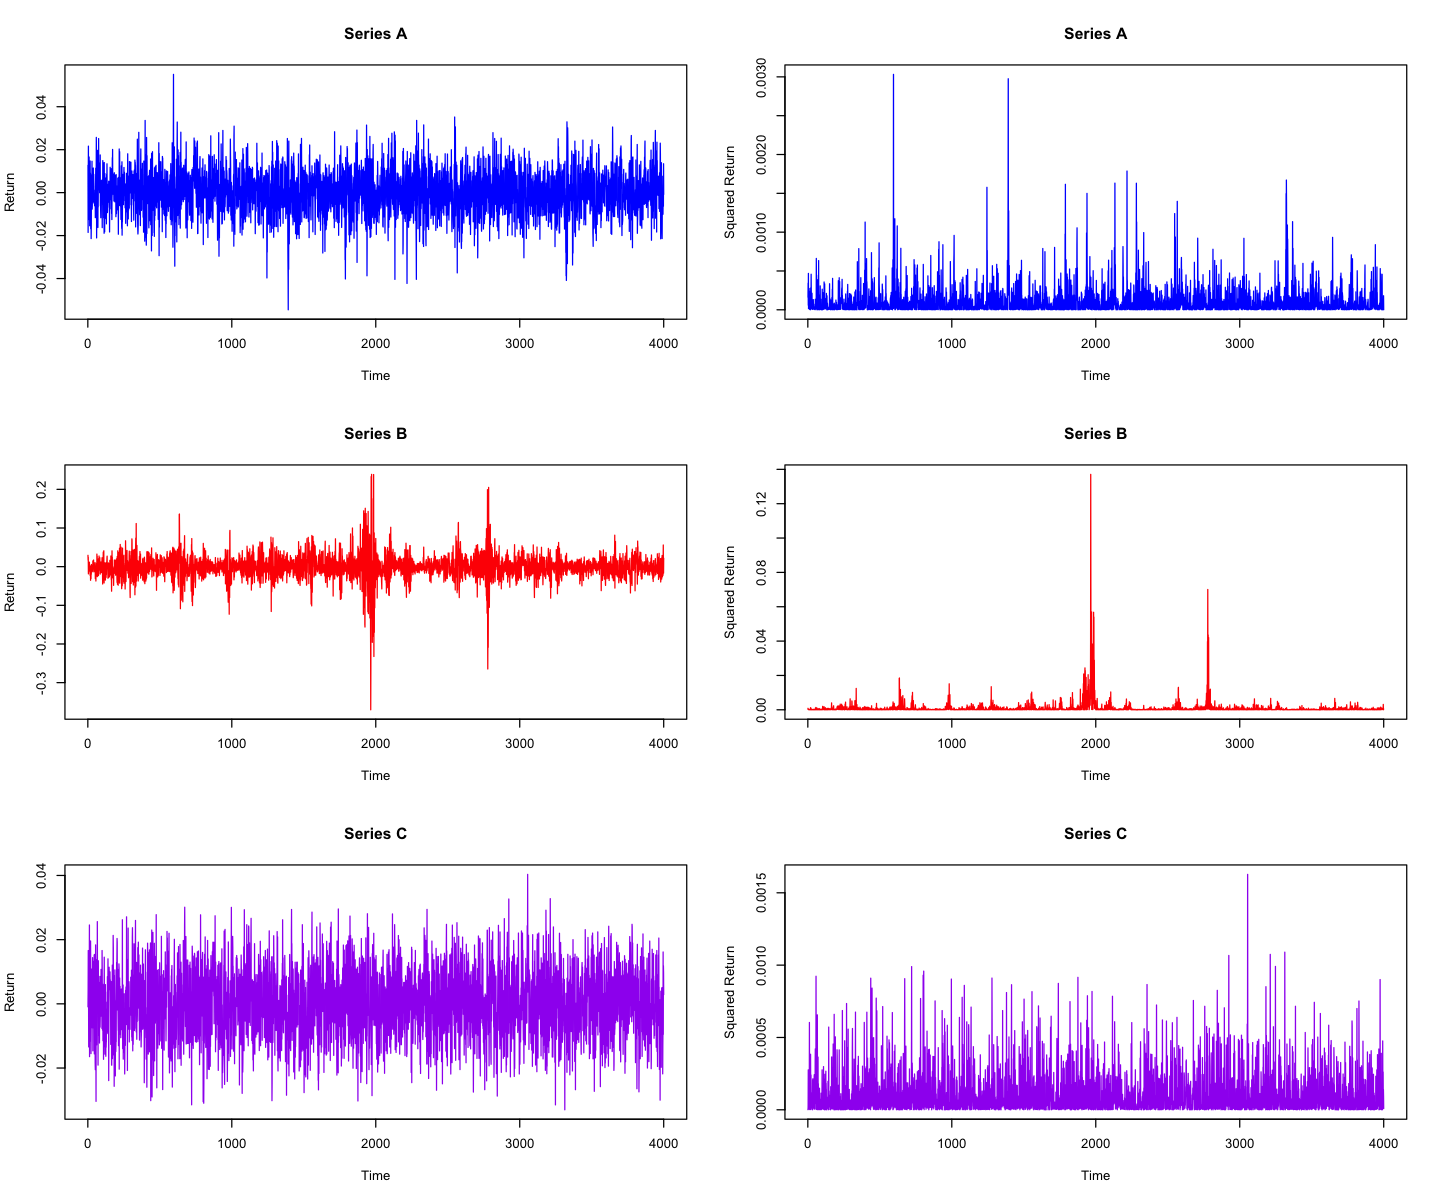

In [79]:
options(repr.plot.height=10, repr.plot.width=12)
par(mfrow=c(3, 2))
ts.plot(seriesA$ret, col="blue", ylab="Return", main="Series A")
ts.plot(seriesA$ret^2, col="blue", ylab="Squared Return", main="Series A")

ts.plot(seriesB$ret, col="red", ylab="Return", main="Series B")
ts.plot(seriesB$ret^2, col="red", ylab="Squared Return", main="Series B")

ts.plot(seriesC$ret, col="purple", ylab="Return", main="Series C")
ts.plot(seriesC$ret^2, col="purple", ylab="Squared Return", main="Series C")

From comparing both return series and return^2 series (proxy for volatility, since returns appear to have a mean close to 0), it appears that:
- **Series B**: while it exhibits the highest degree of volatility clustering (high alpha - reactiveness), it appears to be relatively short lived (the series mean-reverts quickly, moderate beta); strongest GARCH effects
- **Series A**: appears to be the series with moderate volatility clustering spread over the sample. Nevertheless the persistence of these clusters appear to last longer than Series B (higher beta).
- **Series C**: exhibits the lowest degree of GARCH dynamics - it has rather constant variance, with no sustained and obvious clustering.

To be confirmed from further analysis..

## Problem 2: Identification of the conditional mean

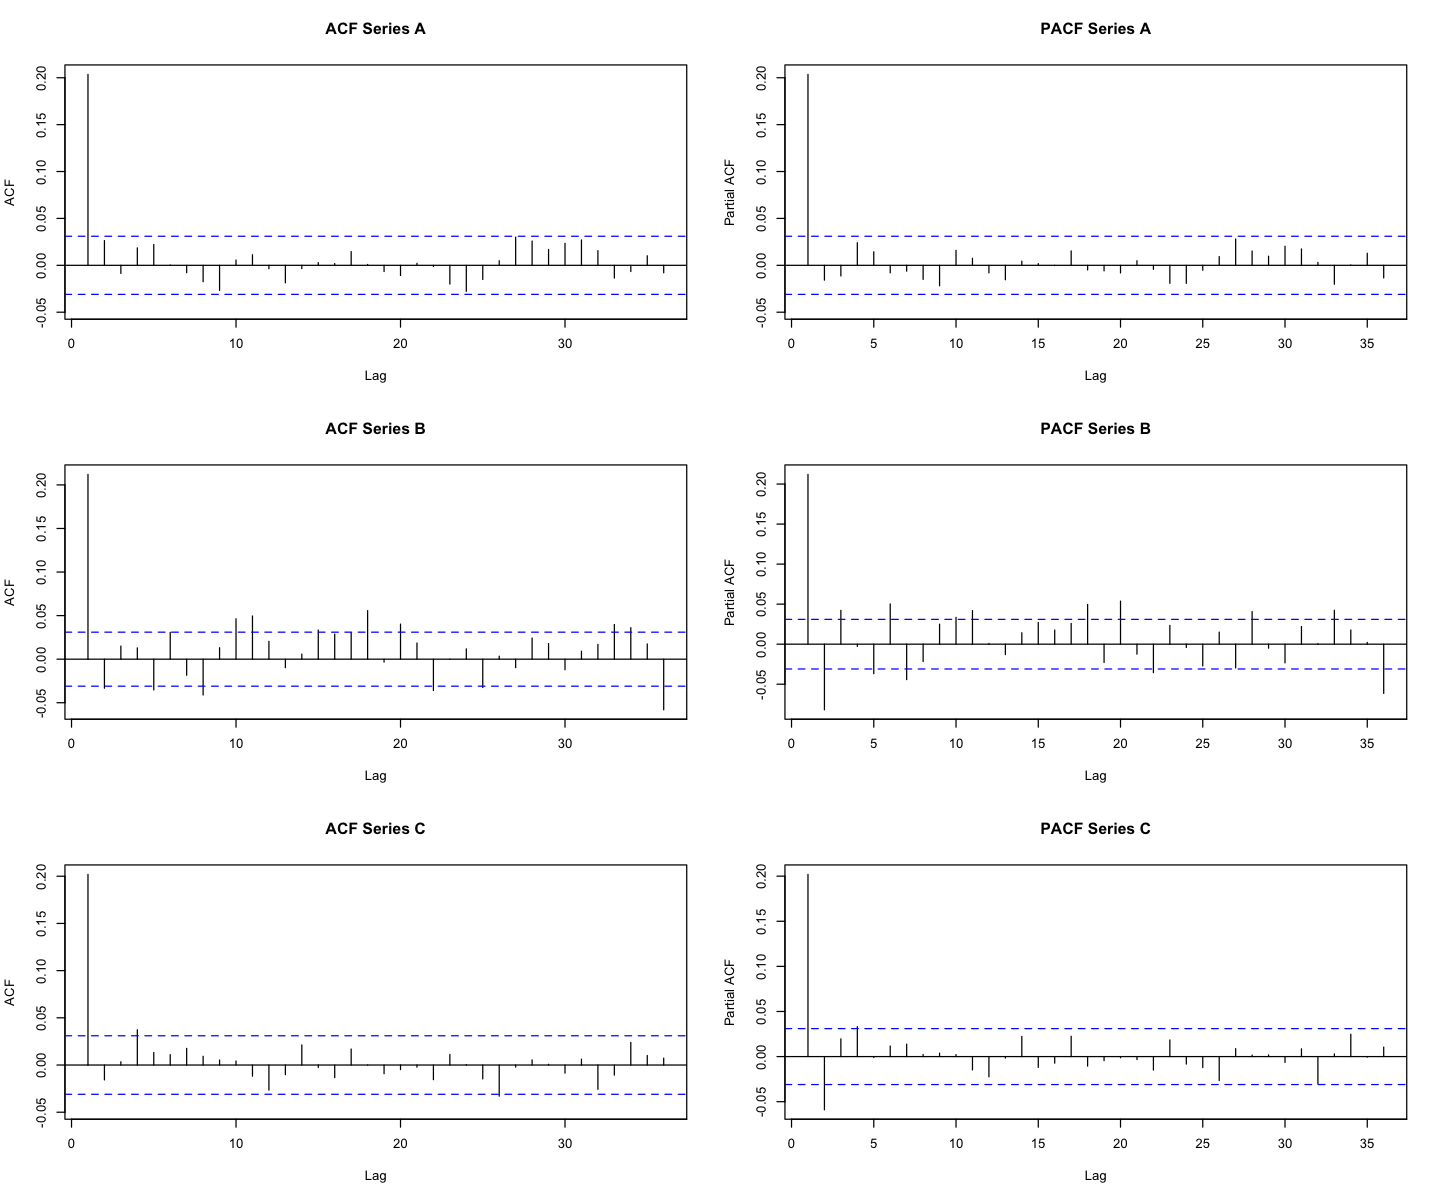

In [80]:
par(mfrow=c(3,2))
Acf(seriesA$ret, main="ACF Series A")
Pacf(seriesA$ret, main="PACF Series A")
Acf(seriesB$ret, main="ACF Series B")
Pacf(seriesB$ret, main="PACF Series B")
Acf(seriesC$ret, main="ACF Series C")
Pacf(seriesC$ret, main="PACF Series C")

Potential ARMA specifications based on ACF/PACF:

**Series A**: ARMA(0,1), ARMA(0,0), ARMA(1,1) (unlikely)
- The ACF cuts off after the first lag, every other is whithin confidence bands - this suggests MA(1). The $\theta$ coefficient being very small could justify the sharp cutoff in PACF. It could also simply be white noise (ARMA(0,0)), since all but 1 lags are within conficence bands.

**Series B**: ARMA(7,2), ARMA(3,1), ARMA(3,2) 
- It becomes very hard to judge the process, as the significance of lag autocorrelations persist at high lags and no clear cutoff pattern
- High order ARMA is likely overfitting from GARCH contamination

**Series C**: ARMA(2,1), ARMA(4,1), ARMA(4,4)
- Lags 1 and 4 are significant in ACF, suggesting MA up to order 4, however 1st lag in ACF and 2nd in PACF seem the most significant
- Lags 1, 2, 4 are significant in PACF, suggesting AR of order up to 4
---

### Model fitting
#### Series A

Series: seriesA$ret 
ARIMA(0,0,1) with non-zero mean 

Coefficients:
         ma1   mean
      0.1999  2e-04
s.e.  0.0150  2e-04

sigma^2 = 0.0001019:  log likelihood = 12707.3
AIC=-25408.61   AICc=-25408.6   BIC=-25389.72

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -2.603314e-07 0.01009445 0.007882723 1355.575 1465.362 0.7847918
                    ACF1
Training set 0.006410327


	Box-Ljung test

data:  A_arma01$residuals
X-squared = 6.0273, df = 4, p-value = 0.1971



	Box-Ljung test

data:  A_arma01$residuals
X-squared = 8.1659, df = 8, p-value = 0.4174



	Box-Ljung test

data:  A_arma01$residuals
X-squared = 11.665, df = 12, p-value = 0.473


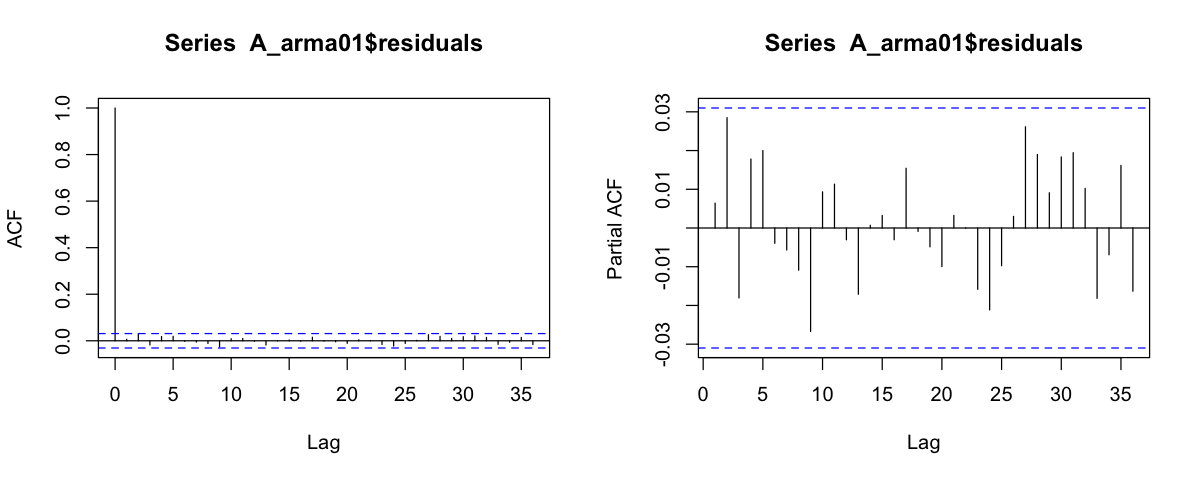

In [81]:
A_arma01 <- Arima(seriesA$ret, order=c(0,0,1))
summary(A_arma01)

options(repr.plot.height=4, repr.plot.width=10)
par(mfrow=c(1,2))
acf(A_arma01$residuals)
pacf(A_arma01$residuals)

Box.test(A_arma01$residuals, type="Ljung-Box", lag=4)
Box.test(A_arma01$residuals, type="Ljung-Box", lag=8)
Box.test(A_arma01$residuals, type="Ljung-Box", lag=12)

We fail to reject the null of joint insignificance of residual autocorrelation.

Series: seriesA$ret 
ARIMA(0,0,0) with non-zero mean 

Coefficients:
       mean
      2e-04
s.e.  2e-04

sigma^2 = 0.0001063:  log likelihood = 12623.99
AIC=-25243.98   AICc=-25243.97   BIC=-25231.39

Training set error measures:
                       ME       RMSE         MAE       MPE     MAPE     MASE
Training set 8.682665e-16 0.01030696 0.007992027 -42.08775 247.7776 0.795674
                  ACF1
Training set 0.2036069


	Box-Ljung test

data:  A_arma00$residuals
X-squared = 170.41, df = 4, p-value < 2.2e-16



	Box-Ljung test

data:  A_arma00$residuals
X-squared = 173.87, df = 8, p-value < 2.2e-16



	Box-Ljung test

data:  A_arma00$residuals
X-squared = 177.42, df = 12, p-value < 2.2e-16


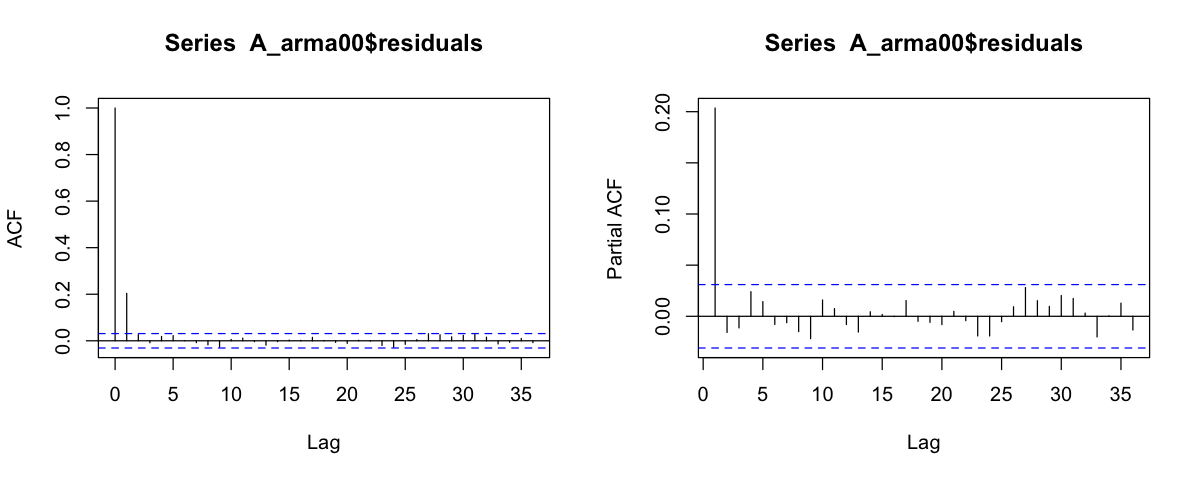

In [82]:
A_arma00 <- Arima(seriesA$ret, order=c(0,0,0))
summary(A_arma00)

par(mfrow=c(1,2))
acf(A_arma00$residuals)
pacf(A_arma00$residuals)

Box.test(A_arma00$residuals, type="Ljung-Box", lag=4)
Box.test(A_arma00$residuals, type="Ljung-Box", lag=8)
Box.test(A_arma00$residuals, type="Ljung-Box", lag=12)

From the ACF and the formal test, we observe that ARMA(0,0) does not eliminate residual autocorrelation - the null of joint insignificance is rejected for all lags tested.

Series: seriesA$ret 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
         ar1     ma1   mean
      0.1381  0.0684  2e-04
s.e.  0.0713  0.0716  2e-04

sigma^2 = 0.0001019:  log likelihood = 12709.13
AIC=-25410.25   AICc=-25410.24   BIC=-25385.08

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 1.343319e-07 0.01008985 0.007880469 1538.757 1654.216 0.7845675
                   ACF1
Training set 9.9461e-05


	Box-Ljung test

data:  A_arma00$residuals
X-squared = 170.41, df = 4, p-value < 2.2e-16



	Box-Ljung test

data:  A_arma00$residuals
X-squared = 173.87, df = 8, p-value < 2.2e-16



	Box-Ljung test

data:  A_arma00$residuals
X-squared = 177.42, df = 12, p-value < 2.2e-16


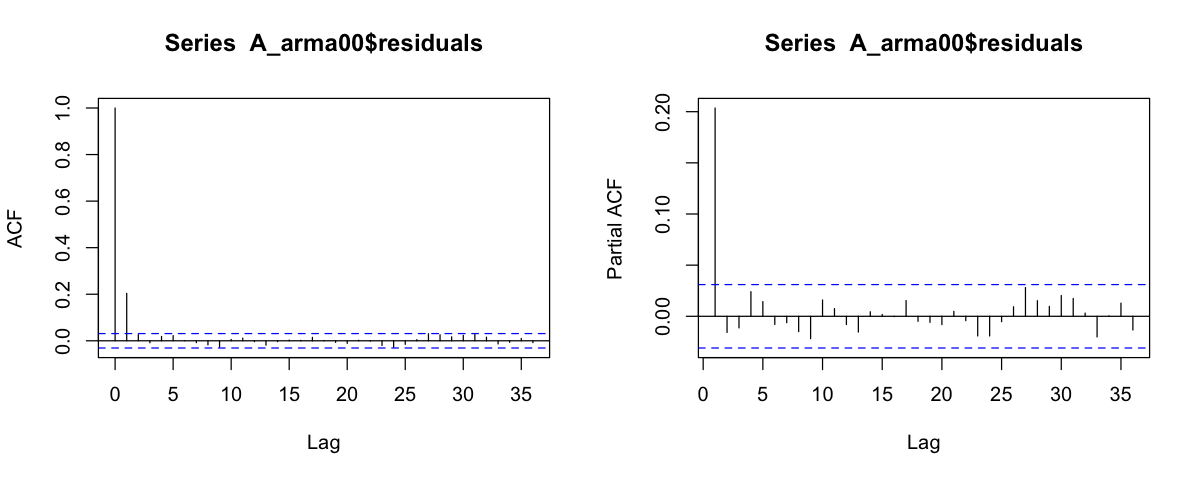

In [83]:
A_arma11 <- Arima(seriesA$ret, order=c(1,0,1))
summary(A_arma11)

par(mfrow=c(1,2))
acf(A_arma00$residuals)
pacf(A_arma00$residuals)

Box.test(A_arma00$residuals, type="Ljung-Box", lag=4)
Box.test(A_arma00$residuals, type="Ljung-Box", lag=8)
Box.test(A_arma00$residuals, type="Ljung-Box", lag=12)

Similarly, ARMA(1,1) is not appropriate as indicated by both the rejection of the null of joint residual autocorrelation and the ACF - we do observe residual autocorrelation after fitting this model.

Series: seriesA$ret 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
         ar1   mean
      0.2036  2e-04
s.e.  0.0155  2e-04

sigma^2 = 0.0001019:  log likelihood = 12708.68
AIC=-25411.36   AICc=-25411.35   BIC=-25392.47

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -7.247933e-09 0.01009098 0.007879242 1587.931 1701.394 0.7844453
                    ACF1
Training set 0.003204518


	Box-Ljung test

data:  A_arma10$residuals
X-squared = 3.34, df = 4, p-value = 0.5026



	Box-Ljung test

data:  A_arma10$residuals
X-squared = 5.6332, df = 8, p-value = 0.6882



	Box-Ljung test

data:  A_arma10$residuals
X-squared = 9.3926, df = 12, p-value = 0.6691


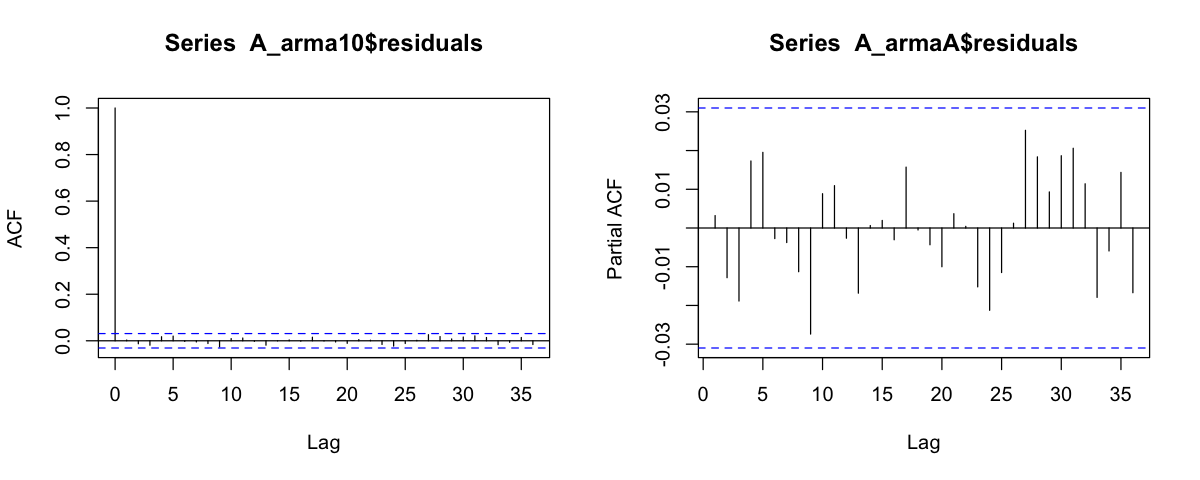

In [84]:
A_arma10 <- Arima(seriesA$ret, order=c(1,0,0))
summary(A_arma10)

par(mfrow=c(1,2))
acf(A_arma10$residuals)
pacf(A_armaA$residuals)

Box.test(A_arma10$residuals, type="Ljung-Box", lag=4)
Box.test(A_arma10$residuals, type="Ljung-Box", lag=8)
Box.test(A_arma10$residuals, type="Ljung-Box", lag=12)

Upon further inspection, it appears that ARMA(1,0) is more appropriate candidate than some of the hypothesized ones above. We cannot reject the null and the ACF and PACF show no residual autocorrelation.

**Top candidates for series A**:
- ARMA(0,1)
- ARMA(1,0)
---

#### Series B

Series: seriesB$ret 
ARIMA(7,0,2) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ar4      ar5     ar6      ar7      ma1
      0.6878  -0.7747  0.2135  -0.0579  -0.0321  0.0764  -0.0824  -0.4536
s.e.  0.1402   0.1343  0.0404   0.0268   0.0236  0.0195   0.0169   0.1404
         ma2    mean
      0.5801  -8e-04
s.e.  0.1253   6e-04

sigma^2 = 0.000928:  log likelihood = 8294.14
AIC=-16566.29   AICc=-16566.22   BIC=-16497.05

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 3.231685e-05 0.03042503 0.02007446 132.6448 213.5471 0.7821786
                    ACF1
Training set 0.001331049


	Box-Ljung test

data:  B_arma72$residuals
X-squared = 0.046735, df = 4, p-value = 0.9997



	Box-Ljung test

data:  B_arma72$residuals
X-squared = 1.3152, df = 8, p-value = 0.9954



	Box-Ljung test

data:  B_arma72$residuals
X-squared = 9.4281, df = 12, p-value = 0.666



	Box-Ljung test

data:  B_arma72$residuals
X-squared = 76.153, df = 35, p-value = 7.003e-05


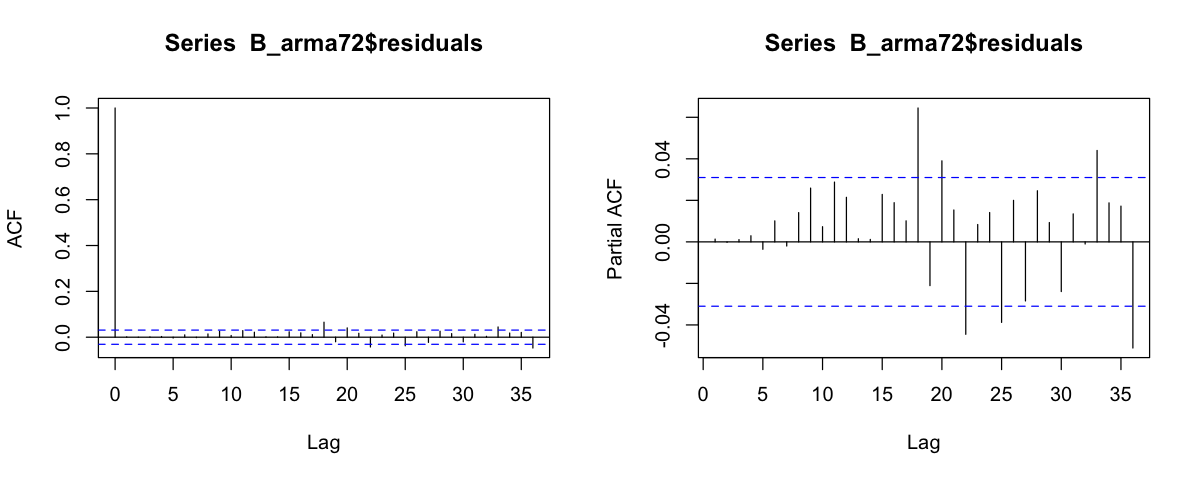

In [85]:
B_arma72 <- Arima(seriesB$ret, order=c(7,0,2))
summary(B_arma72)

par(mfrow=c(1,2))
acf(B_arma72$residuals)
pacf(B_arma72$residuals)

Box.test(B_arma72$residuals, type="Ljung-Box", lag=4)
Box.test(B_arma72$residuals, type="Ljung-Box", lag=8)
Box.test(B_arma72$residuals, type="Ljung-Box", lag=12)
Box.test(B_arma72$residuals, type="Ljung-Box", lag=35)

While all coefficients appear to be significant, the Ljung-Box null cannot be rejected (for lower lags), we observe high autocorrelation at higher lags (PACF), which is also strongly supported by the formal test.

These results strongly suggest GARCH contamination and that any order ARMA we attempt to fit, will either be innapropriate, or overfit the data.

Nevertheless, we proceed with fitting other models to follow the assignment (different from the initially hypothesised ones, as at this stage we have more information about the behaviour of the AR and MA terms)

Series: seriesB$ret 
ARIMA(15,0,1) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ar4      ar5     ar6      ar7     ar8
      0.9843  -0.2653  0.1046  -0.0162  -0.0641  0.0986  -0.0806  0.0014
s.e.  0.1112   0.0341  0.0247   0.0230   0.0227  0.0234   0.0237  0.0231
         ar9    ar10    ar11    ar12     ar13    ar14    ar15      ma1    mean
      0.0405  0.0094  0.0216  -0.026  -0.0175  0.0189  0.0221  -0.7521  -7e-04
s.e.  0.0229  0.0228  0.0228   0.023   0.0226  0.0224  0.0175   0.1104   7e-04

sigma^2 = 0.0009252:  log likelihood = 8303.6
AIC=-16571.2   AICc=-16571.03   BIC=-16457.91

Training set error measures:
                       ME       RMSE        MAE      MPE     MAPE      MASE
Training set 6.463701e-06 0.03035293 0.02005657 129.5991 222.9638 0.7814816
                      ACF1
Training set -7.623954e-05


	Box-Ljung test

data:  B_arma_bigAR$residuals
X-squared = 0.0058571, df = 4, p-value = 1



	Box-Ljung test

data:  B_arma_bigAR$residuals
X-squared = 0.012233, df = 8, p-value = 1



	Box-Ljung test

data:  B_arma_bigAR$residuals
X-squared = 0.058958, df = 12, p-value = 1



	Box-Ljung test

data:  B_arma_bigAR$residuals
X-squared = 101.02, df = 40, p-value = 3.467e-07


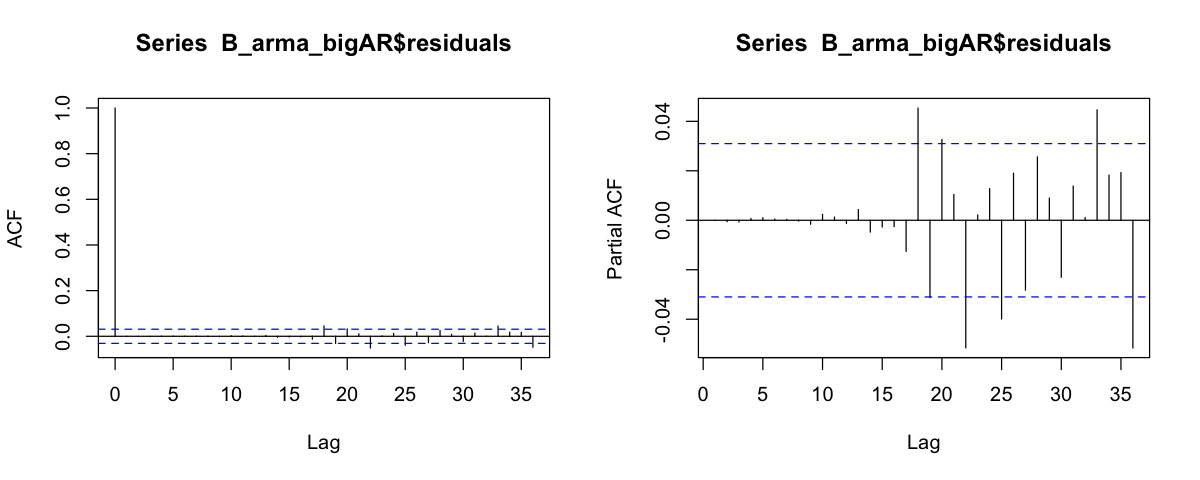

In [86]:
B_arma_bigAR <- Arima(seriesB$ret, order=c(15,0,1))
summary(B_arma_bigAR)

par(mfrow=c(1,2))
acf(B_arma_bigAR$residuals)
pacf(B_arma_bigAR$residuals)

Box.test(B_arma_bigAR$residuals, type="Ljung-Box", lag=4)
Box.test(B_arma_bigAR$residuals, type="Ljung-Box", lag=8)
Box.test(B_arma_bigAR$residuals, type="Ljung-Box", lag=12)
Box.test(B_arma_bigAR$residuals, type="Ljung-Box", lag=40)

It is evident that in order to eliminate the residual autocorrelation in PACF by fitting only an ARMA model, it would necessitate very high order AR terms. The MA part appears to be around 1. Attempting to fit more ARMA models to this series is of no use, as we will likely be overfitting the model instead.

Series: seriesB$ret 
ARIMA(6,0,6) with non-zero mean 

Coefficients:
         ar1      ar2     ar3      ar4     ar5      ar6      ma1     ma2
      0.8029  -1.2268  0.3177  -0.5684  0.0767  -0.3543  -0.5696  1.0055
s.e.  0.2682   0.2106  0.3901   0.2475  0.2055   0.0983   0.2707  0.1645
         ma3     ma4     ma5     ma6    mean
      0.0085  0.4695  0.0141  0.4086  -7e-04
s.e.  0.3445  0.1693  0.1614  0.0728   6e-04

sigma^2 = 0.0009263:  log likelihood = 8299.2
AIC=-16570.41   AICc=-16570.3   BIC=-16482.29

Training set error measures:
                        ME       RMSE       MAE      MPE     MAPE      MASE
Training set -4.174933e-05 0.03038641 0.0200811 131.4886 214.8241 0.7824373
                   ACF1
Training set 0.00105286


	Box-Ljung test

data:  B_arma66$residuals
X-squared = 0.034429, df = 4, p-value = 0.9999



	Box-Ljung test

data:  B_arma66$residuals
X-squared = 0.6516, df = 8, p-value = 0.9996



	Box-Ljung test

data:  B_arma66$residuals
X-squared = 2.2345, df = 12, p-value = 0.999



	Box-Ljung test

data:  B_arma66$residuals
X-squared = 65.635, df = 35, p-value = 0.001295


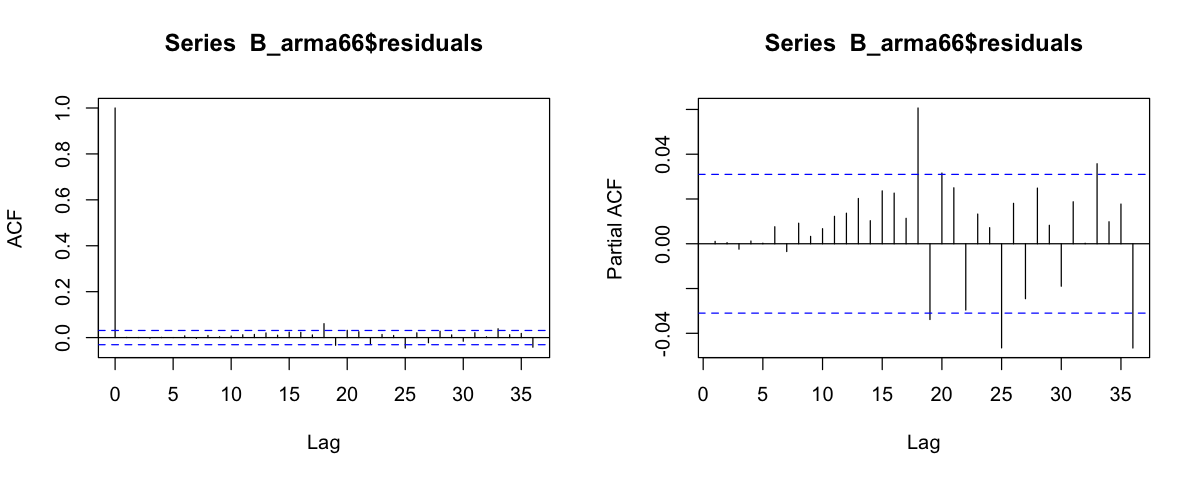

In [87]:
B_arma66 <- Arima(seriesB$ret, order=c(6,0,6))
summary(B_arma66)

par(mfrow=c(1,2))
acf(B_arma66$residuals)
pacf(B_arma66$residuals)

Box.test(B_arma66$residuals, type="Ljung-Box", lag=4)
Box.test(B_arma66$residuals, type="Ljung-Box", lag=8)
Box.test(B_arma66$residuals, type="Ljung-Box", lag=12)
Box.test(B_arma66$residuals, type="Ljung-Box", lag=35)

This model performs similarly to ARMA(15,1). 

**Best candidate**:
- ARMA(15,1)
- ARMA(6,6)

However, we know that these are not appropriate.

#### Series C

Series: seriesC$ret 
ARIMA(2,0,1) with non-zero mean 

Coefficients:
         ar1      ar2     ma1   mean
      0.1046  -0.0379  0.1101  2e-04
s.e.  0.1768   0.0391  0.1767  2e-04

sigma^2 = 0.0001025:  log likelihood = 12698.35
AIC=-25386.7   AICc=-25386.68   BIC=-25355.23

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 1.985483e-08 0.01011707 0.008070224 73.77629 180.9371 0.7784902
                     ACF1
Training set 0.0002081961


	Box-Ljung test

data:  C_arma21$residuals
X-squared = 5.3002, df = 4, p-value = 0.2579



	Box-Ljung test

data:  C_arma21$residuals
X-squared = 6.7053, df = 8, p-value = 0.5687



	Box-Ljung test

data:  C_arma21$residuals
X-squared = 9.0996, df = 12, p-value = 0.6944


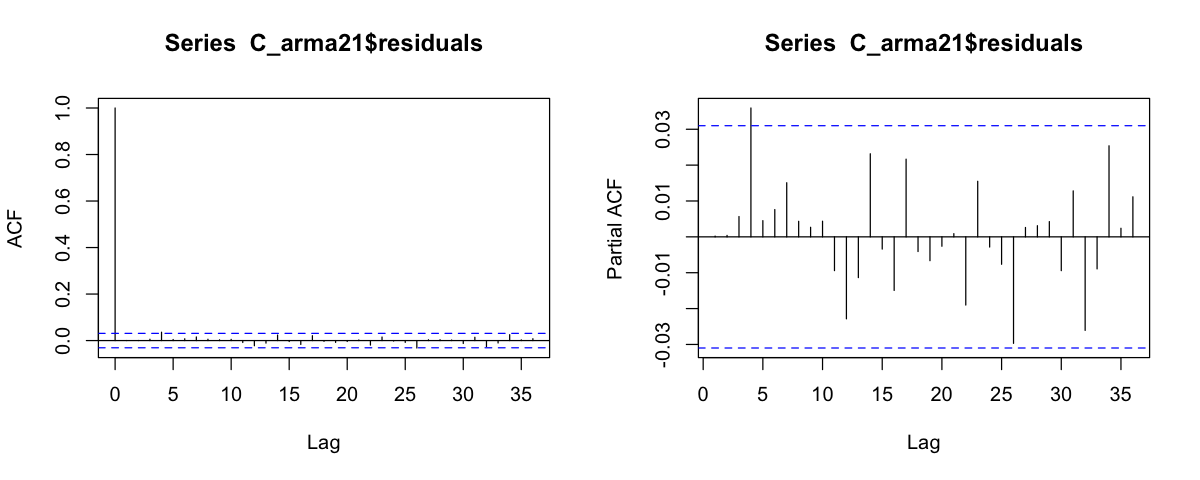

In [92]:
C_arma21 <- Arima(seriesC$ret, order=c(2,0,1))
summary(C_arma21)

par(mfrow=c(1,2))
acf(C_arma21$residuals)
pacf(C_arma21$residuals)

Box.test(C_arma21$residuals, type="Ljung-Box", lag=4)
Box.test(C_arma21$residuals, type="Ljung-Box", lag=8)
Box.test(C_arma21$residuals, type="Ljung-Box", lag=12)

None of the coefficients show to be significant (coeff/s.e.).
Nevetheless, we cannot reject the null of insignificant residual autocorrelation at any of the examined lags. However, we still see one lag (4) in the PACF to be outside of the confidence bounds. We will therefore test ARMA(4,0)

Series: seriesC$ret 
ARIMA(4,0,0) with non-zero mean 

Coefficients:
         ar1      ar2     ar3     ar4   mean
      0.2144  -0.0611  0.0125  0.0332  2e-04
s.e.  0.0158   0.0162  0.0162  0.0158  2e-04

sigma^2 = 0.0001023:  log likelihood = 12700.98
AIC=-25389.97   AICc=-25389.95   BIC=-25352.2

Training set error measures:
                       ME      RMSE         MAE      MPE     MAPE      MASE
Training set 6.776323e-07 0.0101104 0.008064675 71.72275 189.3922 0.7779549
                    ACF1
Training set 6.30207e-05


	Box-Ljung test

data:  C_arma40$residuals
X-squared = 0.0040583, df = 4, p-value = 1



	Box-Ljung test

data:  C_arma40$residuals
X-squared = 1.4177, df = 8, p-value = 0.994



	Box-Ljung test

data:  C_arma40$residuals
X-squared = 3.7955, df = 12, p-value = 0.9869


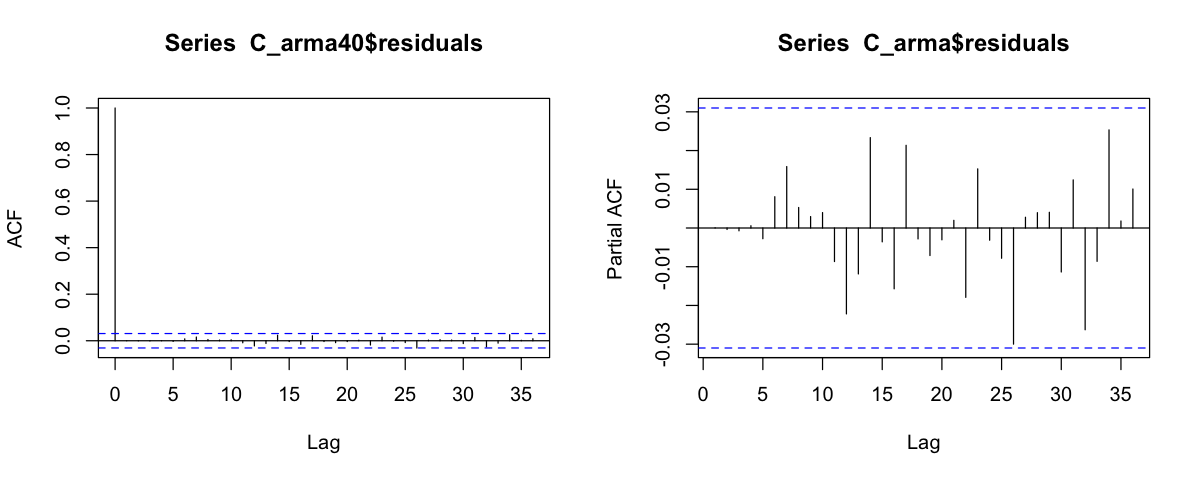

In [96]:
C_arma40 <- Arima(seriesC$ret, order=c(4,0,0))
summary(C_arma40)

par(mfrow=c(1,2))
acf(C_arma40$residuals)
pacf(C_arma$residuals)

Box.test(C_arma40$residuals, type="Ljung-Box", lag=4)
Box.test(C_arma40$residuals, type="Ljung-Box", lag=8)
Box.test(C_arma40$residuals, type="Ljung-Box", lag=12)

Hereby, all residual autocorrelations disappear. We cannot reject the null and the ACF and PACF do not exhibit peculiar behaviour. We are inclined to believe this could be the data generating model.

Series: seriesC$ret 
ARIMA(0,0,4) with non-zero mean 

Coefficients:
         ma1      ma2      ma3     ma4   mean
      0.2141  -0.0153  -0.0049  0.0338  2e-04
s.e.  0.0158   0.0161   0.0160  0.0156  2e-04

sigma^2 = 0.0001024:  log likelihood = 12700.74
AIC=-25389.48   AICc=-25389.46   BIC=-25351.71

Training set error measures:
                       ME       RMSE         MAE      MPE     MAPE      MASE
Training set 5.143586e-08 0.01011101 0.008067254 73.66759 186.5105 0.7782037
                     ACF1
Training set 0.0004494463


	Box-Ljung test

data:  C_arma04$residuals
X-squared = 0.027263, df = 4, p-value = 0.9999



	Box-Ljung test

data:  C_arma04$residuals
X-squared = 1.8539, df = 8, p-value = 0.9852



	Box-Ljung test

data:  C_arma04$residuals
X-squared = 4.1734, df = 12, p-value = 0.9801


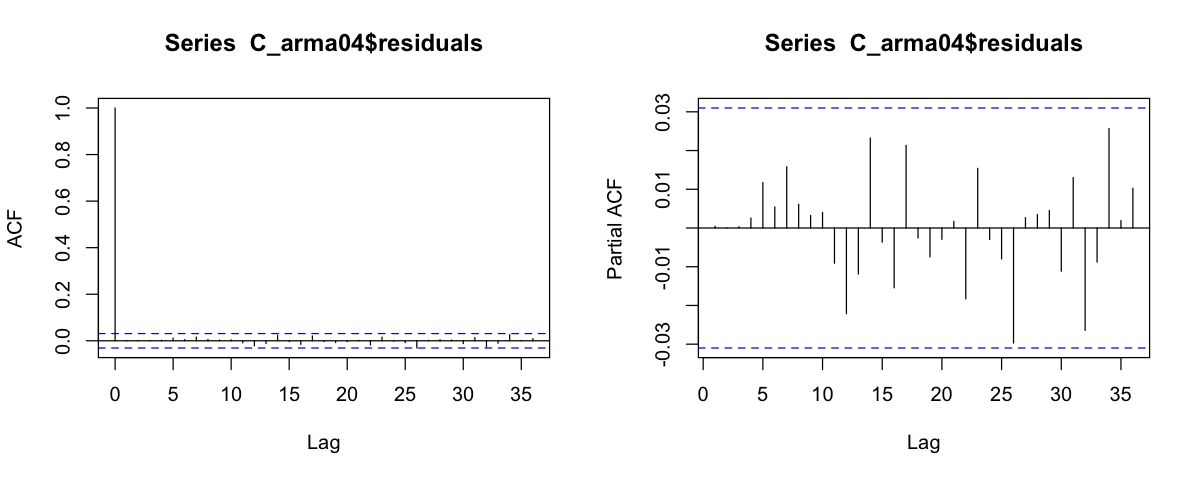

In [104]:
C_arma04 <- Arima(seriesC$ret, order=c(0,0,4))
summary(C_arma04)

par(mfrow=c(1,2))
acf(C_arma04$residuals)
pacf(C_arma04$residuals)

Box.test(C_arma04$residuals, type="Ljung-Box", lag=4)
Box.test(C_arma04$residuals, type="Ljung-Box", lag=8)
Box.test(C_arma04$residuals, type="Ljung-Box", lag=12)

Upon further inspection, ARMA(0,4) also provides a good fit, similar to ARMA(4,0). The behaviour is similar if we even attempt ARMA(4,4) as it can be seen below.

Warning message in sqrt(diag(x$var.coef)):
"NaNs produced"


Series: seriesC$ret 
ARIMA(4,0,4) with non-zero mean 

Coefficients:
         ar1     ar2     ar3     ar4     ma1      ma2      ma3      ma4   mean
      0.1366  0.1202  0.1856  0.0475  0.0776  -0.1646  -0.2132  -0.0471  2e-04
s.e.     NaN     NaN  0.4394     NaN     NaN   0.2798   0.2400      NaN  2e-04

sigma^2 = 0.0001024:  log likelihood = 12701.43
AIC=-25382.85   AICc=-25382.8   BIC=-25319.91

Training set error measures:
                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -2.108073e-06 0.01010927 0.008065659 69.93039 188.3426 0.7780498
                     ACF1
Training set 0.0001389742


	Box-Ljung test

data:  C_arma44$residuals
X-squared = 0.0083559, df = 4, p-value = 1



	Box-Ljung test

data:  C_arma44$residuals
X-squared = 0.29443, df = 8, p-value = 1



	Box-Ljung test

data:  C_arma44$residuals
X-squared = 2.8545, df = 12, p-value = 0.9965


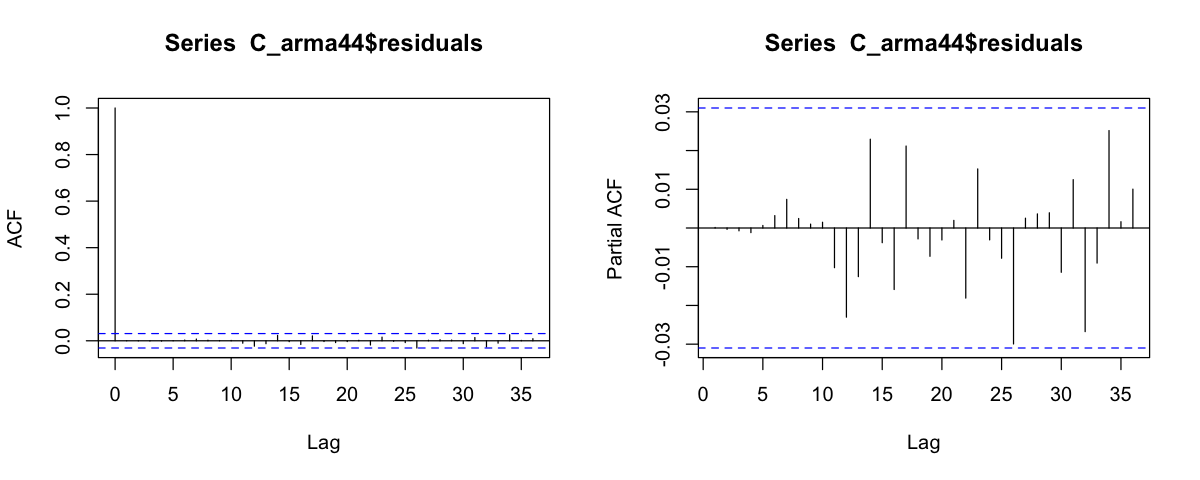

In [105]:
C_arma44 <- Arima(seriesC$ret, order=c(4,0,4))
summary(C_arma44)

par(mfrow=c(1,2))
acf(C_arma44$residuals)
pacf(C_arma44$residuals)

Box.test(C_arma44$residuals, type="Ljung-Box", lag=4)
Box.test(C_arma44$residuals, type="Ljung-Box", lag=8)
Box.test(C_arma44$residuals, type="Ljung-Box", lag=12)

However, this is not the most parsimonuous model and we are likely overfitting at this stage.

**Best candidate models**:
- ARMA(4,0)
- ARMA(0,4)

`Side note`: splitting the model into sub-periods and considering different models for separate periods has not been considered, as we believe the assignment does not ask for that.

---

### Information Criteria comparison

In [107]:
#Put all ICs into a dataframe to present collectively
ic_A <- data.frame(
    Model = c("ARMA(0,1)", "ARMA(1,0)"),
    AIC = c(A_arma01$aic, A_arma10$aic),
    AICc = c(A_arma01$aicc, A_arma10$aicc),
    BIC = c(A_arma01$bic, A_arma10$bic)
)

ic_B <- data.frame(
    Model = c("ARMA(15,1)", "ARMA(6,6)"),
    AIC = c(B_arma_bigAR$aic, B_arma66$aic),
    AICc = c(B_arma_bigAR$aicc, B_arma66$aicc),
    BIC = c(B_arma_bigAR$bic, B_arma66$bic)
)

ic_C <- data.frame(
    Model = c("ARMA(4,0)", "ARMA(0,4)", "ARMA(4,4)"),
    AIC = c(C_arma40$aic, C_arma04$aic, C_arma44$aic),
    AICc = c(C_arma40$aicc, C_arma04$aicc, C_arma44$aicc),
    BIC = c(C_arma40$bic, C_arma04$bic, C_arma44$bic)
)

ic_all <- rbind(
    cbind(Series="A", ic_A),
    cbind(Series="B", ic_B),
    cbind(Series="C", ic_C)
)
ic_all

Series,Model,AIC,AICc,BIC
<chr>,<chr>,<dbl>,<dbl>,<dbl>
A,"ARMA(0,1)",-25408.61,-25408.60,-25389.72
A,"ARMA(1,0)",-25411.36,-25411.35,-25392.47
B,"ARMA(15,1)",-16571.20,-16571.03,-16457.91
B,"ARMA(6,6)",-16570.41,-16570.30,-16482.29
C,"ARMA(4,0)",-25389.97,-25389.95,-25352.20
C,"ARMA(0,4)",-25389.48,-25389.46,-25351.71
C,"ARMA(4,4)",-25382.85,-25382.80,-25319.91


The three examined criteria are defined as follows:

$$AIC = -2\ell(\hat{\theta}) + 2k$$

$$AICc = AIC + \frac{2k(k+1)}{n-k-1}$$

$$BIC = -2\ell(\hat{\theta}) + k\ln(n)$$

where $\ell(\hat{\theta})$ is the log-likelihood evaluated at the estimated parameters,
$k$ is the number of estimated parameters, and $n$ is the sample size.

The AIC and AICc differ with respect to penalization - AIC and AICc both reward fit and penalise complexity. AICc, however, introduces an additional correction term which penalises small sample sizes. Since our series samples are large, AIC and AICc are almost identical.

BIC: The penalty term $k\ln(n)$ grows with both the number of parameters $k$ and 
sample size $n$. For $n > e^2 \approx 7.4$, $\ln(n) > 2$. This means BIC always 
penalises complexity more heavily than AIC. With $n=4000$, $\ln(n) \approx 8.3$, 
around 4x the AIC penalty per parameter.


**Series A**:
Both ARMA(0,1) and ARMA(1,) perform similarly across all criteria, with ARMA(1,0) being negligably preferred across criteria. This suggests that both specifications model the mean equally well.

**Series B**:
AIC/AICc slightly prefer ARMA(15,1). BIC in turn prefers ARMA(6,6) as it finds it to be the more parsimonious specification. Since we suspected Series B to have the highest magnitude of GARCH effects, both specifications examined likely represent overfitting risk.

**Series C**: 
All three candidates perform similarly. AIC prefer ARMA(4,0) slightly (the difference is negligible), similar to BIC (which penalises the more complex ARMA(4,4))

---
Based on the information criteria and ACF/PACF graphs (for the examined specifications), we find the most appropriate ones to be:

**Series A**: ARMA(1,0)
- Unanimously selected by the information criteria by a small amount. Nevertheless, if it were truly an AR(1) process,while we would expect to have 1 significant lag at the PACF, we would also expect to see a slowly decaying ACF (it could be that the memory of this process is very short)

**Series B**: ARMA(6,6)
- The BIC finds the order 6,6 to be less complex, while the AIC(c) does not differentiate substantially between the two models. Neither model manages to eliminate completely the residual autocorrelation - remaining dynamics likely GARCH

**Series C**: ARMA(4,0)
- (4,4) is penalised for complexity, while (4,0) and (0,4) differ minimally based on the criteria. (4,0) has slightly more negative criteria. Such a finding is rather consistent with the PACF, as we see a cutoff around lag 4, while the ACF appears to be decaying in some form.

To be investigated further.

## Problem 3


	ARCH LM-test; Null hypothesis: no ARCH effects

data:  A_arma10$residuals
Chi-squared = 351.23, df = 12, p-value < 2.2e-16



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  B_arma66$residuals
Chi-squared = 1510.2, df = 12, p-value < 2.2e-16



	ARCH LM-test; Null hypothesis: no ARCH effects

data:  C_arma40$residuals
Chi-squared = 6.1265, df = 12, p-value = 0.9096


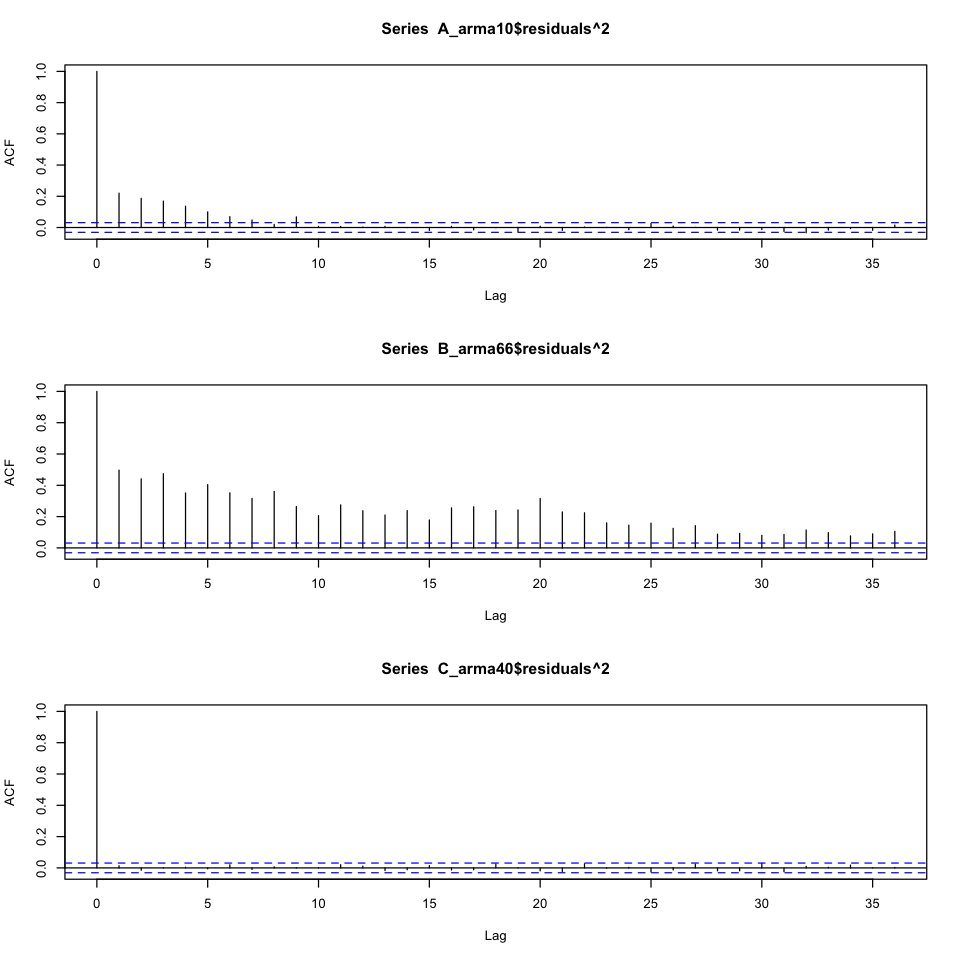

In [126]:
options(repr.plot.height=8, repr.plot.width=8)
par(mfrow=c(3,1))
acf(A_arma10$residuals^2)
acf(B_arma66$residuals^2)
acf(C_arma40$residuals^2)

ArchTest(A_arma10$residuals) #conditional heteroscedasticity test
ArchTest(B_arma66$residuals)
ArchTest(C_arma40$residuals)


Based on the ACFs and the cond. heteroscedasticity tests, we observe that series A and B are not accurately modeled, as there is residual autocorrelation in the squared residuals. These findings reflect the fact that ARMA models only manage to model the conditional mean, and are insufficient to model the conditional variance - need to fit a GARCH model.

The strong rejection of the null in Series A and B (as initially hypothesised) suggests that there are significant ARCH effects remaining after fitting ARMA (especially in Series B).

Meanwhile, Series C exhibits no significant residual^2 autocorrelation at lagged values. This suggessts that ARMA(4,0) is sufficient specification of the conditional mean - no evidence of ARCH effects, which aligns with out initial hypothesis from Problem 1.

- Since financial data tend to exhibit volatility clustering (conditinal heteroscedasticity), an ARMA model, which treats all observations equally (calm and turbulent period observations should not be treated as such) is not able to accurately fit such data. ARCH or GARCH models on the other hand, account for time varying estimates of $\sigma_t^2$, which can be used to standardise residuals. This leads to improvement in parameter estimation (when estimating parameters jointly ARMA-GARCH), as such a model accounts for heteroscedasticity in the error term. Consequently, we get better inference when we account for volatility clustering - otherwise heteroscedastic residuals would inflate SEs and make significance tests unreliable.